In [24]:
import argparse
import sys
sys.path.append('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/')
from har_snn import *

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from rockpool.devices.xylo.syns63300 import XyloSamna, config_from_specification, mapper, XyloSim, Quantizer
from rockpool_transform_quantize_methods import global_quantize, channel_quantize

import wandb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.metrics import classification_report, balanced_accuracy_score, f1_score, matthews_corrcoef, cohen_kappa_score

In [32]:
device = torch.device('cuda')

tc = 1.0

kwargs = {}
kwargs.update([('shiftSyn', 2), ('shiftMem', 1)])
kwargs['timeResolution'] = 1./64*tc
kwargs['tausFactor'] = 1.0 / tc

model = createModel(
    'SynNetRP',
    inputSize=15,
    outputSize=13,
    hiddenSizes=[80,80,80],
    device=device,
    sampleFreq=64,
    **kwargs
)

model_name = f'2026-03-16T19:51:17.414649963+00:00_hbg44sf6.pth' # 'NIMU_tc1.pth' # 
state_dict = torch.load('/home/igavier_umass_edu/Documents/Neuromorphic-IMU/snn/models/'
                        + model_name, weights_only=True)

# ####################################
# # If using Wisdm dataset
# state = state_dict['seq.out_linear.weight']
# state = torch.cat([state[:,:1], state[:,[1,8,9,11]].mean(1, keepdim=True), state[:,2:8], state[:,10:11], state[:,12:]], dim=1)
# state_dict['seq.out_linear.weight'] = state
# state = state_dict['seq.out_neurons.vmem']
# state = torch.cat([state[:1], state[[1,8,9,11]].mean(0, keepdim=True), state[2:8], state[10:11], state[12:]], dim=0)
# state_dict['seq.out_neurons.vmem'] = state
# state = state_dict['seq.out_neurons.isyn']
# state = torch.cat([state[:1], state[[1,8,9,11]].mean(0, keepdim=True), state[2:8], state[10:11], state[12:]], dim=0)
# state_dict['seq.out_neurons.isyn'] = state
# state = state_dict['seq.out_neurons.spikes']
# state = torch.cat([state[:1], state[[1,8,9,11]].max(0, keepdim=True)[0], state[2:8], state[10:11], state[12:]], dim=0)
# state_dict['seq.out_neurons.spikes'] = state

model.load_state_dict(state_dict)
# with torch.no_grad():
#     model.seq['0_linear'].weight /= (0.05 * 2 ** 15)
# model.reset_state()

<All keys matched successfully>

In [33]:
data_path = (f'/work/pi_sunghoonlee_umass_edu/Ignacio/mhealth/' +
             f'data/spikesXylo/windows/')
             # f'data/eventsNIMU/windows/')
             # f'data/realworld_wg/windows/')

train_loader, val_loader, test_loader = createLoaders(
    data_path,
    datasetName='MHealth',
    labelType='Willetts2018',
    subjectSplits=[80,10,10],
    batchSize=64,
    randomSeed=10,
    balance=True,
    sampleFreq=64,
    rectifySpikes=False,
    polarityBichannel=False,
    timeCompress=tc,
    timeResolution=1./64*tc,
    systemType='downsampled',
    quantizeSpikes=False
)

Subject splits: [array([1, 3, 2, 4, 7, 9, 5, 6]), array([0]), array([8])]
Subject splits: [array([1, 3, 2, 4, 7, 9, 5, 6]), array([0]), array([8])]
Subject splits: [array([1, 3, 2, 4, 7, 9, 5, 6]), array([0]), array([8])]


In [34]:
normal_arr = next(iter(test_loader))[0][2].numpy().T
N = normal_arr.shape[1]

(0.0, 3.0)

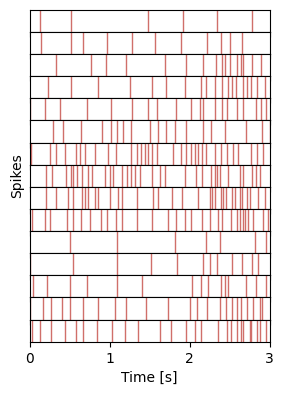

In [35]:
fig, ax = plt.subplots(15, 1, figsize=(3,4), sharex=True, sharey=True)
plt.subplots_adjust(bottom=0.12, top=0.95, left=0.1, right=0.9, hspace=0)
# fig, ax = plt.subplots(3, 1, figsize=(3,2), sharex=True, sharey=True)
# plt.subplots_adjust(bottom=0.22, top=0.95, left=0.1, right=0.9, hspace=0)

for i, axi in enumerate(ax):
    axi.set_yticks([])
    x = 10/N*np.arange(N)
    y = normal_arr[i]
    # axi.stem(x, y, linefmt=f'C{i//5}', markerfmt='', basefmt=f'C{i//5}')
    # axi.scatter(x[y!=0], np.ones_like(y)[y!=0], s=10*np.abs(y[y!=0]), marker='|', c=f'C{i//5}')
    # axi.scatter(x, np.zeros_like(x), s=2, c='#d06f6aff', marker='^')
    axi.vlines(x=x[y!=0], ymin=0, ymax=10, colors='#d06f6aff', linewidth=(y**(1/2))[y!=0])
    # axi.plot(x, y, color='#d06f6aff', linewidth=2)
    # axi.set_title(rf'$\sigma=${[f"{2/2**j:.3f} s" for j in range(5)][i%5]}, {"XYZ"[i//5]}-axis', y=1.0, pad=-14)
    # axi.set_yticks([0], [])
    # axi.tick_params(axis='y', direction='in')
    # axi.grid(axis='y')

axi.set_xlabel('Time [s]')
ax[int(len(ax)//2)].set_ylabel(r'Spikes')
axi.set_ylim(0,10)
axi.set_xlim(0,3)
# fig.savefig('./../results/spikes_with_downsampling_nimu.pdf', dpi=150)

# Simulation environment

In [36]:
specs = mapper(model.as_graph(), weight_dtype='float', threshold_dtype='float')
specsq = deepcopy(specs)
specsq.update(global_quantize(**specsq, fuzzy_scaling = False))
config, is_valid, msg = config_from_specification(**specsq, spiking_input=False)
modSim = XyloSim.from_config(config, dt=specsq['dt'])

In [37]:
from rockpool.devices.xylo.syns63300 import cycles_model, est_clock_freq
print(f"This network requires {cycles_model(config)} master clock cycles per network time-step.")
print(f"This network requires a master clock of {est_clock_freq(config, specsq['dt']) / 1e6:.2f} MHz")

This network requires 103450.0 master clock cycles per network time-step.
This network requires a master clock of 7.94 MHz


In [38]:
# import pickle

# with open(f'./../snn/models/NIMU_tc{int(tc)}.npy', 'wb') as f:
#     pickle.dump(specsq, f)
np.save(f'./../snn/models/Xylo_mhealth_model_tc{int(tc)}.npy', config)

In [11]:
scaling_rec = np.round(np.linalg.norm(specsq['weights_in']) / np.linalg.norm(specs['weights_in']))
scaling_out = np.round(np.linalg.norm(specsq['weights_out']) / np.linalg.norm(specs['weights_out']))

print(scaling_rec, scaling_out)

127.0 127.0


In [13]:
i = 11
batch = next(iter(test_loader))
input_spikes = batch[0].detach().numpy()
labels = batch[1].detach().numpy()
# input_spikes[:,:,:] = 0
# input_spikes[:,320,0] = 80

model.reset_state()
modSim.reset_state()
out1, _, r_d1 = model(torch.tensor(input_spikes[i]).unsqueeze(0).float().cuda(), record = True)
out2, _, r_d2 = modSim(input_spikes[i], record = True)

2


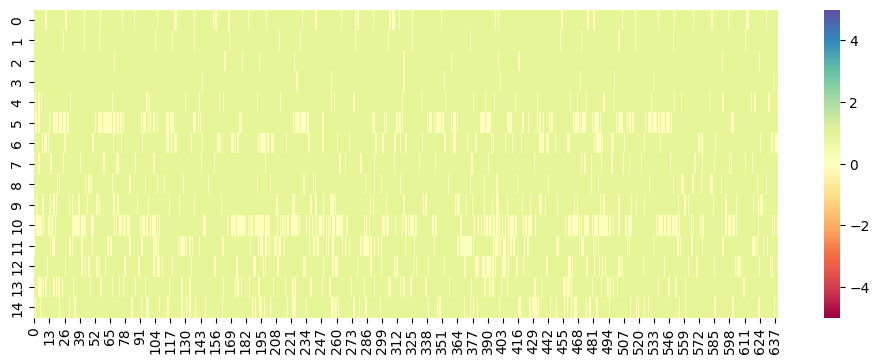

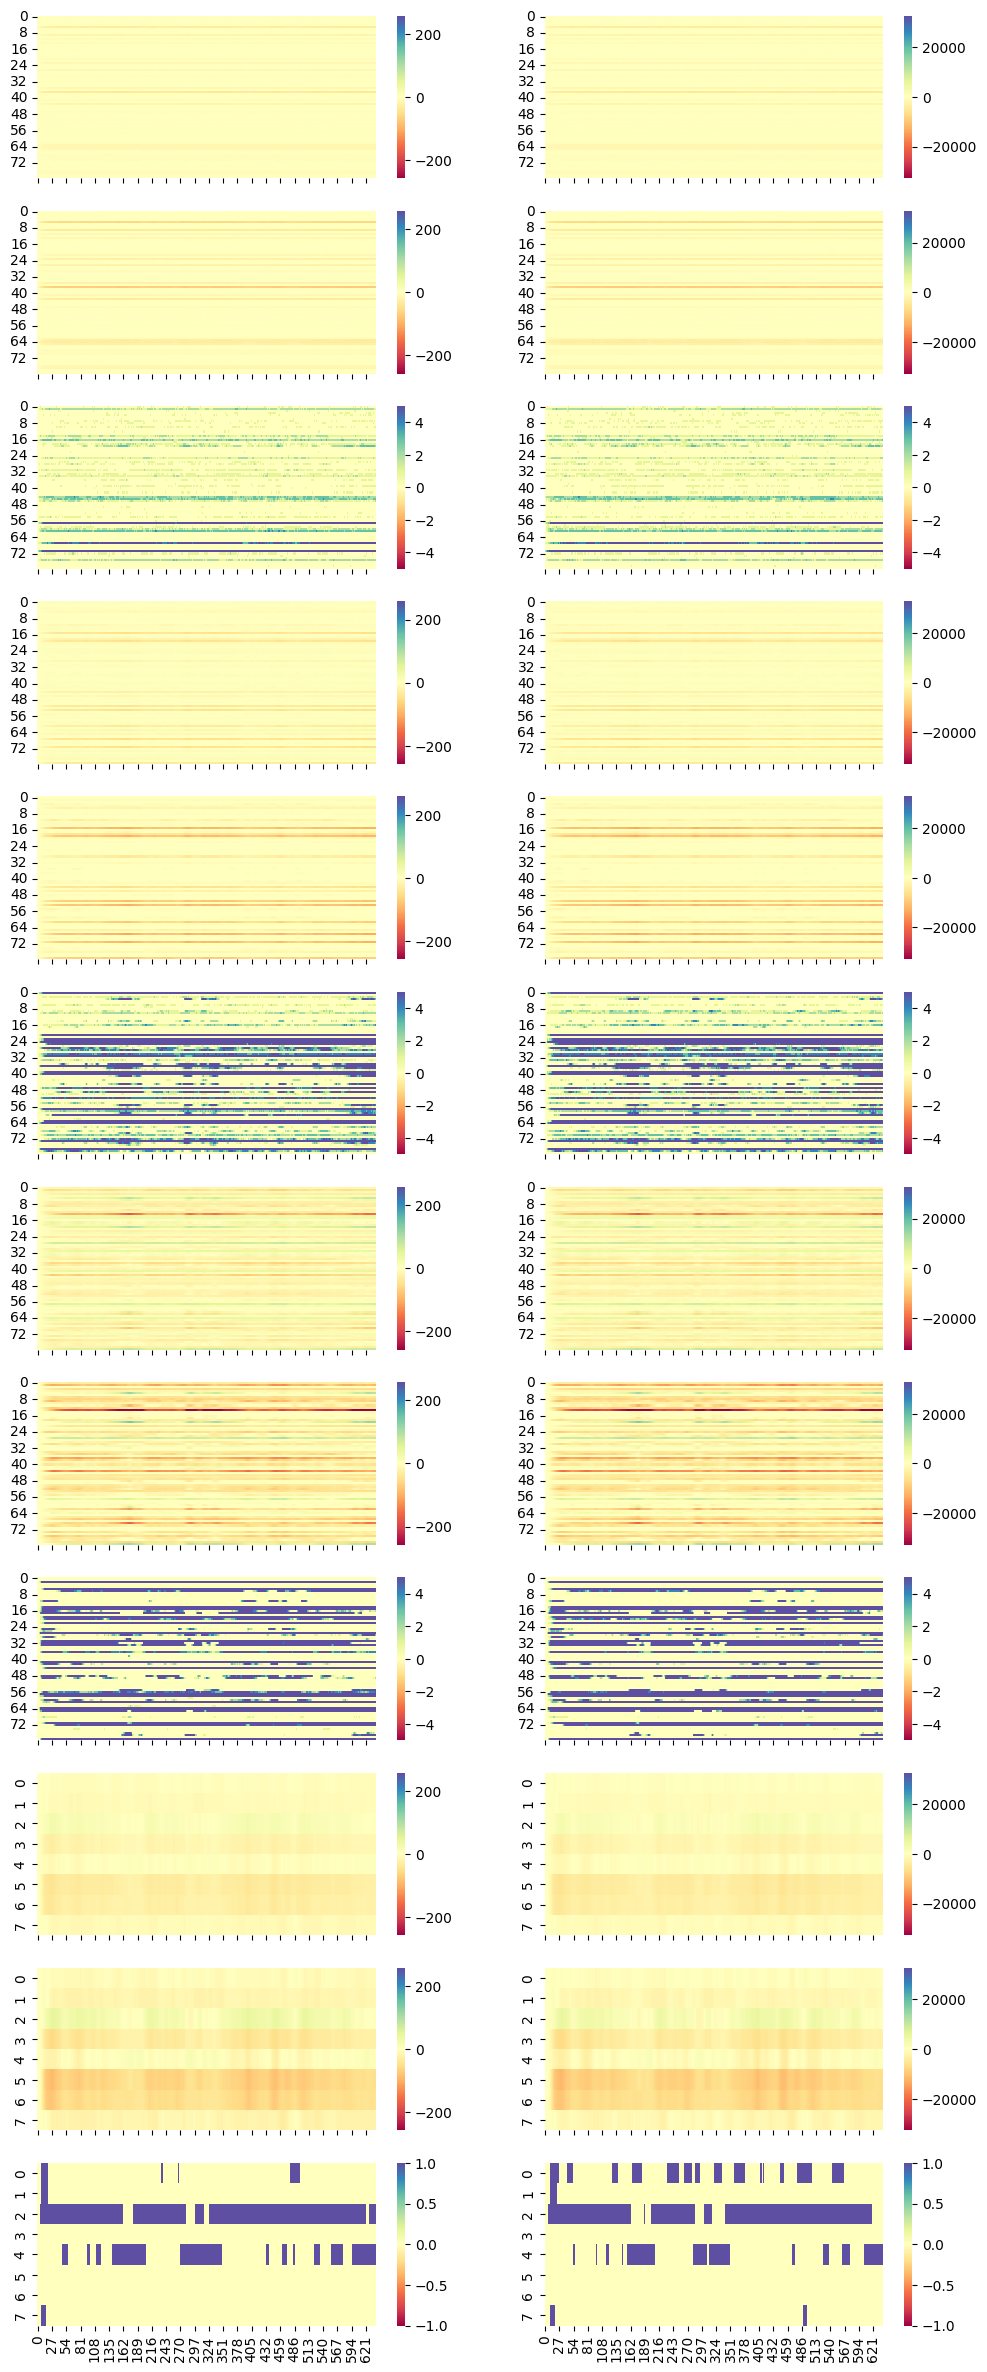

In [14]:
L = 4

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
print(labels[i])
sn.heatmap(input_spikes[i].T, vmin=-5, vmax=5, cmap='Spectral', ax=ax)

fig, ax = plt.subplots(L*3, 2, figsize=(12, 6*(L+1)), sharex=True)

# model.reset_state()
for i in range(L):
    lyr = 'out' if i == 3 else i
    isyn = r_d1[f'{lyr}_neurons']['isyn'].squeeze().detach().cpu().numpy().T
    vmem = r_d1[f'{lyr}_neurons']['vmem'].squeeze().detach().cpu().numpy().T
    spk = r_d1[f'{lyr}_neurons']['spikes'].squeeze().detach().cpu().numpy().T
    v = 2 ** 15 / (scaling_out if i == 3 else scaling_rec)
    sn.heatmap(isyn, vmin=-v, vmax=v, cmap='Spectral', ax=ax[3*i,0])
    sn.heatmap(vmem, vmin=-v, vmax=v, cmap='Spectral', ax=ax[3*i+1,0])
    v = 1 if i == 3 else 5
    sn.heatmap(spk, vmin=-v, vmax=v, cmap='Spectral', ax=ax[3*i+2,0])

for i in range(L):
    isyn = r_d2['Isyn_out'].squeeze().T if i == 3 else r_d2['Isyn'].squeeze().T[i*80:(i+1)*80]
    vmem = r_d2['Vmem_out'].T if i == 3 else r_d2['Vmem'].T[i*80:(i+1)*80]
    spk = out2.T if i == 3 else r_d2['Spikes'].T[i*80:(i+1)*80]
    v = 2 ** 15
    sn.heatmap(isyn, vmin=-v, vmax=v, cmap='Spectral', ax=ax[3*i,1])
    sn.heatmap(vmem, vmin=-v, vmax=v, cmap='Spectral', ax=ax[3*i+1,1])
    v = 1 if i == 3 else 5
    sn.heatmap(spk, vmin=-v, vmax=v, cmap='Spectral', ax=ax[3*i+2,1])

In [15]:
inputs, labels = [], []
for inp, lab in test_loader:
    inputs.append(inp.numpy())
    labels.append(lab.numpy())
inputs, labels = np.concatenate(inputs, 0), np.concatenate(labels, 0)

In [20]:
preds1, scores1 = [], []
preds2, scores2 = [], []

model.reset_state()
modSim.reset_state()

for inp, lbl in tqdm(zip(inputs, labels)):
    out, _, r_d = model(torch.tensor(inp).unsqueeze(0).float().cuda(), record = False)
    out = out.squeeze().detach().cpu().numpy()
    score = (out + 1e-6).sum(0) / (out + 1e-6).sum()
    pred = np.argmax(score)

    scores1.append(score)
    preds1.append(pred)
    
    out, _, r_d = modSim(inp, record = False)
    score = (out + 1e-6).sum(0) / (out + 1e-6).sum()
    pred = np.argmax(score)

    scores2.append(score)
    preds2.append(pred)

    print(lbl, preds1[-1], preds2[-1])

preds1 = np.array(preds1)
scores1 = np.stack(scores1, axis=0)
preds2 = np.array(preds2)
scores2 = np.stack(scores2, axis=0)

1it [00:01,  1.18s/it]

5 3 3


2it [00:02,  1.22s/it]

4 4 4


3it [00:03,  1.23s/it]

...

2 2 2


295it [06:04,  1.22s/it]

5 3 5


296it [06:05,  1.24s/it]

1 0 0


In [21]:
(preds1 == labels).mean()

np.float64(0.5844594594594594)

In [22]:
(preds2 == labels).mean()

np.float64(0.581081081081081)

<Axes: >

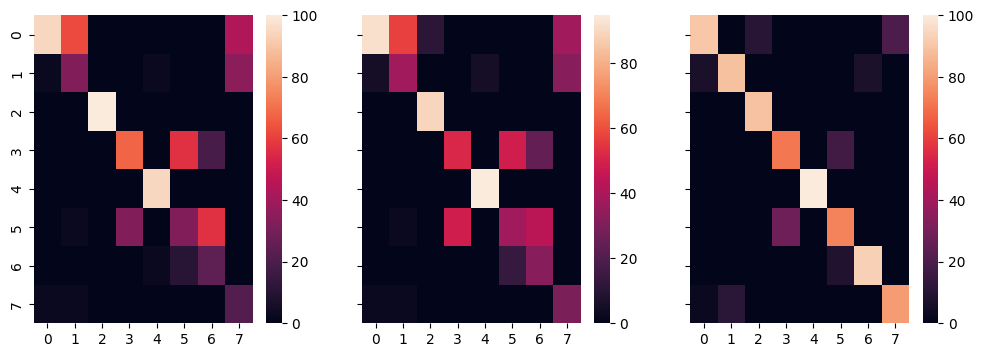

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(12,4), sharex=True, sharey=True)

sn.heatmap(confusion_matrix(labels, preds1, normalize='true').T*100, ax=ax[0])
sn.heatmap(confusion_matrix(labels, preds2, normalize='true').T*100, ax=ax[1])
sn.heatmap(confusion_matrix(preds1, preds2, normalize='true').T*100, ax=ax[2])